<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival by 

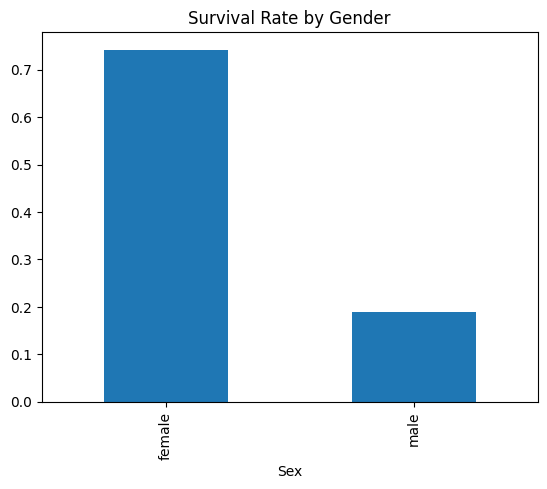

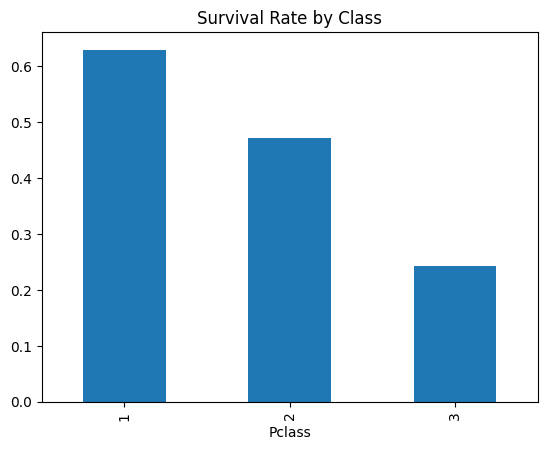


Survival by Age Group:
 AgeGroup
Child         0.579710
Teen          0.428571
Adult         0.360465
Middle Age    0.390625
Senior        0.227273
Name: Survived, dtype: float64


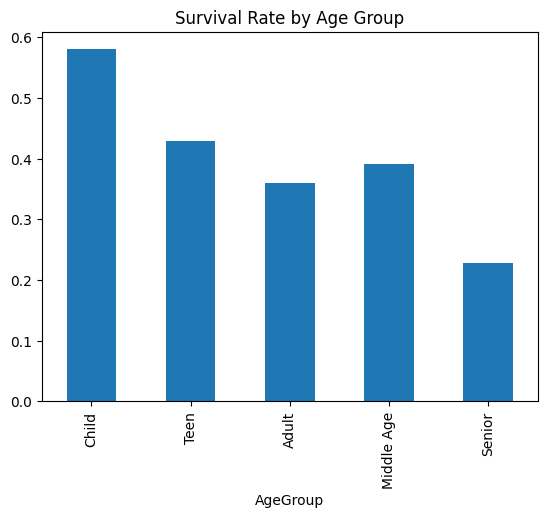

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")

# --------------------------
# 1. Basic Info
# --------------------------
print(df.info())
print(df.isnull().sum())

# --------------------------
# 2. Data Cleaning
# --------------------------
# Fill missing Age
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Drop Cabin (too many missing)
df.drop('Cabin', axis=1, inplace=True)

# --------------------------
# 3. Survival Analysis
# --------------------------

# Survival by Gender
survival_gender = df.groupby('Sex')['Survived'].mean()
print("\nSurvival by Gender:\n", survival_gender)

# Survival by Class
survival_class = df.groupby('Pclass')['Survived'].mean()
print("\nSurvival by Class:\n", survival_class)

# --------------------------
# 4. Visualization (🔥 important)
# --------------------------

survival_gender.plot(kind='bar', title='Survival Rate by Gender')
plt.show()

survival_class.plot(kind='bar', title='Survival Rate by Class')
plt.show()

# --------------------------
# 5. Age Group Analysis
# --------------------------

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 40, 60, 100],
                       labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior'])

age_survival = df.groupby('AgeGroup')['Survived'].mean()
print("\nSurvival by Age Group:\n", age_survival)

age_survival.plot(kind='bar', title='Survival Rate by Age Group')
plt.show()